# Crypto Price Prediction Project



## 1. Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX

## 2. Load and Inspect Data


In [3]:
# Load data
data = pd.read_csv("DOGE-USD.csv", parse_dates=['Date'])

# Print correlation matrix
display(data.corr())

# Check for null values
if data.isnull().any().any():
    print("Null values found. Dropping them.")
    data.dropna(inplace=True)

# Set date as index
data.set_index('Date', inplace=True)

# Print summary statistics
display(data.describe())

C:\Users\ankur\AppData\Local\Temp\ipykernel_8972\3684992456.py:5: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  display(data.corr())


,Open,High,Low,Close,Adj Close,Volume
Open,1.000000,0.993904,0.993707,0.992514,0.992514,0.554850
High,0.993904,1.000000,0.986497,0.995104,0.995104,0.619321
Low,0.993707,0.986497,1.000000,0.994575,0.994575,0.519991
Close,0.992514,0.995104,0.994575,1.000000,1.000000,0.588678
Adj Close,0.992514,0.995104,0.994575,1.000000,1.000000,0.588678
Volume,0.554850,0.619321,0.519991,0.588678,0.588678,1.000000


Null values found. Dropping them.


,Open,High,Low,Close,Adj Close,Volume
count,1760.000000,1760.000000,1760.000000,1760.000000,1760.000000,1.760000e+03
mean,0.059575,0.063096,0.056126,0.059619,0.059619,1.016258e+09
std,0.101325,0.109152,0.093695,0.101379,0.101379,3.563999e+09
min,0.001046,0.001210,0.001002,0.001038,0.001038,1.431720e+06
25%,0.002550,0.002616,0.002500,0.002548,0.002548,2.307671e+07
50%,0.003476,0.003603,0.003356,0.003495,0.003495,8.981855e+07
75%,0.070633,0.075035,0.068478,0.070657,0.070657,6.565853e+08
max,0.687801,0.737567,0.608168,0.684777,0.684777,6.941068e+10


## 3. Visualize Close Price Over Time


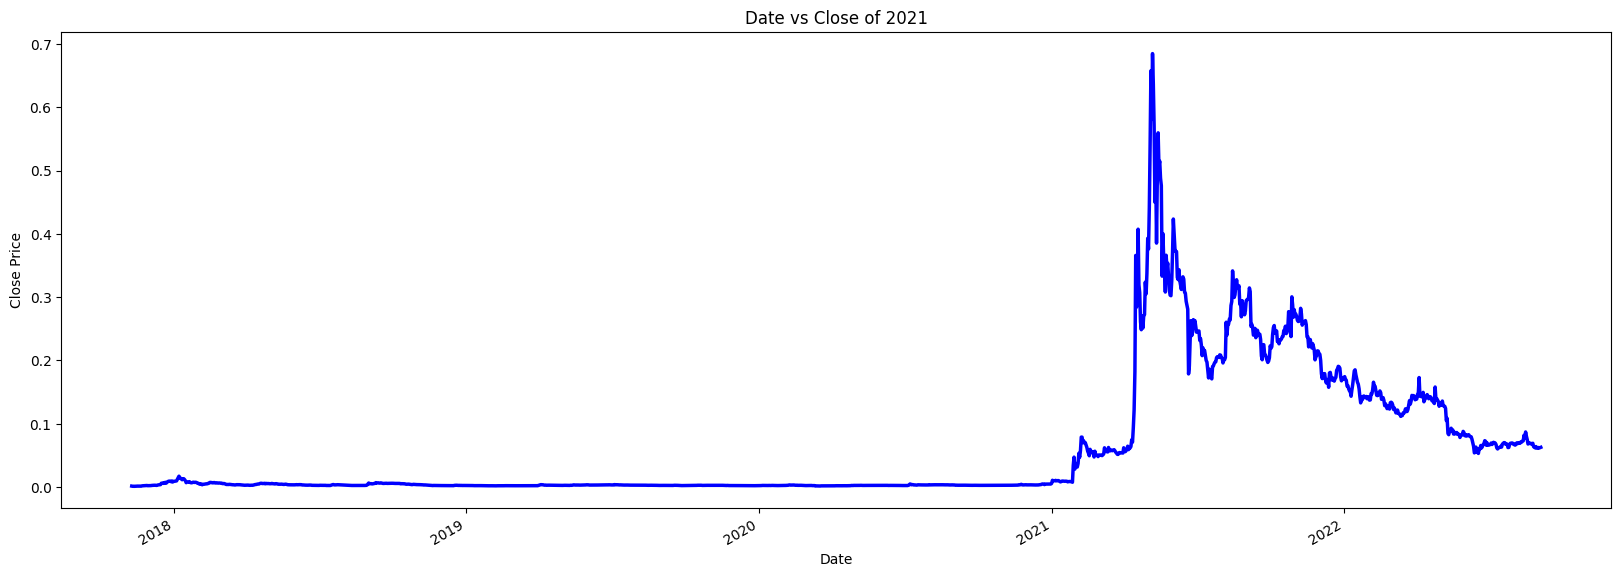

In [4]:
plt.figure(figsize=(20, 7))
data['Close'].plot(linewidth=2.5, color='b')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title("Date vs Close of 2021")
plt.show()

## 4. Feature Engineering


In [5]:
# Create new features
data["gap"] = (data["High"] - data["Low"]) * data["Volume"]
data["y"] = data["High"] / data["Volume"]
data["z"] = data["Low"] / data["Volume"]
data["a"] = data["High"] / data["Low"]
data["b"] = (data["High"] / data["Low"]) * data["Volume"]

# Print correlation with close price
display(abs(data.corr()["Close"].sort_values(ascending=False)))

Close        1.000000
Adj Close    1.000000
High         0.995104
Low          0.994575
Open         0.992514
Volume       0.588678
b            0.456479
gap          0.383333
a            0.172057
z            0.063251
y            0.063868
Name: Close, dtype: float64

## 5. Select Features and Prepare Data


In [6]:
# Select relevant features
data = data[["Close", "Volume", "gap", "a", "b"]]

# Print first few rows
display(data.head())

,Close,Volume,gap,a,b
Date,,,,,
2017-11-09,0.001415,6259550.0,1464.73470,1.198137,7.499800e+06
2017-11-10,0.001163,4246520.0,1299.43512,1.272000,5.401573e+06
2017-11-11,0.001201,2231080.0,258.80528,1.101665,2.457903e+06
2017-11-12,0.001038,3288960.0,684.10368,1.207585,3.971698e+06
2017-11-13,0.001211,2481270.0,478.88511,1.189401,2.951226e+06


## 6. Split Data into Training and Testing Sets
Divide the data into training and testing sets for model evaluation.

In [7]:
# Split data into training and testing sets
df2 = data.tail(30)
train = df2[:11]
test = df2[-19:]

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

Train Shape: (11, 5)
Test Shape: (19, 5)


## 7. Build and Fit SARIMAX Model


In [8]:
# Create and fit SARIMAX model
model = SARIMAX(endog=train["Close"], exog=train[["Volume", "gap", "a", "b"]], order=(2, 1, 1))
results = model.fit()

# Print model summary
display(results.summary())

C:\Users\ankur\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\ankur\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\ankur\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\ankur\AppData\Roaming\Python\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Close   No. Observations:                   11
Model:               SARIMAX(2, 1, 1)   Log Likelihood                  47.663
Date:                Thu, 20 Nov 2025   AIC                            -79.326
Time:                        21:58:03   BIC                            -76.905
Sample:                    08-05-2022   HQIC                           -81.981
                         - 08-15-2022                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Volume      7.491e-10   1.84e-10      4.077      0.000    3.89e-10    1.11e-09
gap          1.13e-08   2.45e-09      4.615      0.000     6.5e-09    1.61e-08
a             -0.0073   5.05e-15  -1.44e+12      0.000      -0.007      -0.007
b          -7.541e-10   1.83e-10     -4.126      0.000   -1.11e-09   -3.96e-10
ar.L1              -0   8.45e-15         -0      1.000   -1.66e-14    1.66e-14
ar.L2               0   2.59e-14          0      1.000   -5.07e-14    5.07e-14
ma.L1         -0.5015   1.87e-14  -2.68e+13      0.000      -0.501      -0.501
sigma2      3.673e-07   5.67e-08      6.481      0.000    2.56e-07    4.78e-07
===================================================================================
Ljung-Box (L1) (Q):                   0.15   Jarque-Bera (JB):                 0.51
Prob(Q):                              0.70   Prob(JB):                         0.77
Heteroskedasticity (H):               0.40   Skew:                            -0.54
Prob(H) (two-sided):                  0.47   Kurtosis:                         2.72
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 4.61e+29. Standard errors may be unstable.
"""

## 8. Make Predictions and Visualize Results


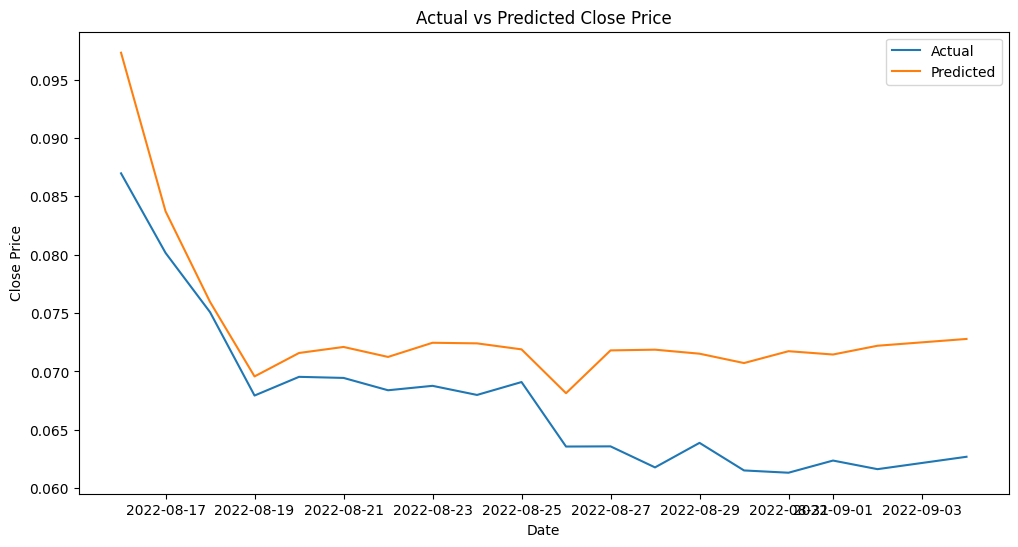

In [9]:
# Make predictions
start = 11
end = 29
predictions = results.predict(start=start, end=end, exog=test.drop("Close", axis=1))

# Plot actual vs predicted close price
plt.figure(figsize=(12, 6))
plt.plot(test.index, test["Close"], label='Actual')
plt.plot(test.index, predictions, label='Predicted')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title("Actual vs Predicted Close Price")
plt.legend()
plt.show()